---
numbering:
  enumerator: "17.%s"
  equation:
    template: "%s"  
---

(chap_causality)=
# Two key concepts: causality and non-stationarity

A prominent point of criticism faced by ML tools is their inability to uncover **causality** relationships between features and labels because they are mostly focused (by design) to capture correlations. Correlations are much weaker than causality because they characterize a two-way relationship ($\textbf{X}\leftrightarrow \textbf{y}$), while causality specifies a direction $\textbf{X}\rightarrow \textbf{y}$ or $\textbf{X}\leftarrow \textbf{y}$. One fashionable example is sentiment. Many academic articles seem to find that sentiment (irrespectively of its definition) is a significant driver of future returns. A high sentiment for a particular stock may increase the demand for this stock and push its price up (though contrarian reasonings may also apply: if sentiment is high, it is a sign that mean-reversion is possibly about to happen). The reverse causation is also plausible: returns may well cause sentiment. If a stock experiences a long period of market growth, people become bullish about this stock and sentiment increases (this notably comes from extrapolation, see @barberis2015x for a theoretical model). In @coqueret2018economic, it is found (in opposition to most findings in this field), that the latter relationship (returns $\rightarrow$ sentiment) is more likely. This result is backed by causality driven tests (see Section {ref}`sec_granger`).

Statistical causality is a large field and we refer to @pearl2009causality for a deep dive into this topic. Recently, researchers have sought to link causality with ML approaches (see, e.g., @peters2017elements, @heinze2018invariant, @arjovsky2019invariant). The key notion in their work is **invariance**.

Often, data is collected not at once, but from different sources at different moments. Some relationships found in these different sources will change, while others may remain the same. The relationships that are invariant to **changing environments** are likely to stem from (and signal) causality. One counter-example is the following (related in @beery2018recognition): training a computer vision algorithm to discriminate between cows and camels will lead the algorithm to focus on grass versus sand! This is because most camels are pictured in the desert while cows are shown in green fields of grass. Thus, a picture of a camel on grass will be classified as cow, while a cow on sand would be labelled "camel". It is only with pictures of these two animals in different contexts (environments) that the learner will end up truly finding what makes a cow and a camel. A camel will remain a camel no matter where it is pictured: it should be recognized as such by the learner. If so, the representation of the camel becomes invariant over all datasets and the learner has discovered causality, i.e., the true attributes that make the camel a camel (overall silhouette, shape of the back, face, color (possibly misleading!), etc.).

This search for invariance makes sense for many disciplines like computer vision or natural language processing (cats will always look like cats and languages don't change much). In finance, it is not obvious that invariance may exist. Market conditions are known to be time-varying and the relationships between firm characteristics and returns also change from year to year. One solution to this issue may simply be to embrace **non-stationarity** (see Section {ref}`sec_notations` for a definition of stationarity). In Chapter {ref}`chap_backtest`, we advocate to do that by updating models as frequently as possible with rolling training sets: this allows the predictions to be based on the most recent trends. In Section {ref}`sec_nonstat` below, we introduce other theoretical and practical options.

## Causality

Traditional machine learning models aim to uncover relationships between variables but do not usually specify *directions* for these relationships. One typical example is the linear regression. If we write $y=a+bx+\epsilon$, then it is also true that $x=b^{-1}(y-a-\epsilon)$, which is of course also a linear relationship (with respect to $y$). These equations do not define causation whereby $x$ would be a clear determinant of $y$ ($x \rightarrow y$, but the opposite could be false).

Recently, @dacunto2021evolving have investigated the causal structure of prominent equity factors. The study, via the the VAR-LiNGAM technique of @hyvarinen2010estimation, finds that risk factor interactions are continuously evolving.

### Granger causality {#sec_granger}

The most notable tool first proposed by @granger1969investigating is probably the simplest. For simplicity, we consider only two stationary processes, $X_t$ and $Y_t$. A strict definition of causality could be the following. $X$ can be said to cause $Y$, whenever, for some integer $k$,

$$(Y_{t+1},\dots,Y_{t+k})|(\mathcal{F}_{Y,t}\cup \mathcal{F}_{X,t}) \quad  \overset{d}{\neq} \quad (Y_{t+1},\dots,Y_{t+k})|\mathcal{F}_{Y,t},$$

that is, when the distribution of future values of $Y_t$, conditionally on the knowledge of both processes is not the same as the distribution with the sole knowledge of the filtration $\mathcal{F}_{Y,t}$. Hence $X$ does have an impact on $Y$ because its trajectory alters that of $Y$.

Now, this formulation is too vague and impossible to handle numerically, thus we simplify the setting via a linear formulation. We keep the same notations as section 5 of the original paper by @granger1969investigating. The test consists of two regressions:

\begin{align*}
X_t&=\sum_{j=1}^ma_jX_{t-j}+\sum_{j=1}^mb_jY_{t-j} + \epsilon_t \\
Y_t&=\sum_{j=1}^mc_jX_{t-j}+\sum_{j=1}^md_jY_{t-j} + \nu_t
\end{align*}

where for simplicity, it is assumed that both processes have zero mean. The usual assumptions apply: the Gaussian noises $\epsilon_t$ and $\nu_t$ are uncorrelated in every possible way (mutually and through time). The test is the following: if one $b_j$ is nonzero, then it is said that $Y$ Granger-causes $X$ and if one $c_j$ is nonzero, $X$ Granger-causes $Y$. The two are not mutually exclusive and it is widely accepted that feedback loops can very well occur.

Statistically, under the null hypothesis, $b_1=\dots=b_m=0$ (*resp.* $c_1=\dots=c_m=0$), which can be tested using the usual Fischer distribution. Obviously, the linear restriction can be dismissed but the tests are then much more complex. The main financial article in this direction is @hiemstra1994testing.

In Python, the `statsmodels` library provides Granger causality testing. The syntax is straightforward. We test if market capitalization Granger-causes 1 month ahead returns for one particular stock.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Building the data & import functions
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

# Define separation date and create samples
separation_date = "2017-01-15"
training_sample = data_ml[data_ml['date'] <= separation_date].dropna()
testing_sample = data_ml[data_ml['date'] > separation_date].dropna()

In [2]:
# Get data for first stock
first_stock = training_sample['fsym_id'].unique()[0]
stock_data = training_sample[training_sample['fsym_id'] == first_stock].copy()
stock_data = stock_data.sort_values('date')

# Prepare data for Granger test (needs 2D array with [y, x])
# Test if size_avg_252d (market cap proxy) Granger-causes R1M
granger_data = stock_data[['R1M', 'size_avg_252d']].dropna()

# Perform Granger causality test
# Tests if the second column Granger-causes the first
print("Testing if size_avg_252d Granger-causes R1M:")
print("="*50)
granger_results = grangercausalitytests(granger_data, maxlag=6, verbose=True)

Testing if size_avg_252d Granger-causes R1M:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8956  , p=0.0502  , df_denom=152, df_num=1
ssr based chi2 test:   chi2=3.9725  , p=0.0462  , df=1
likelihood ratio test: chi2=3.9224  , p=0.0476  , df=1
parameter F test:         F=3.8956  , p=0.0502  , df_denom=152, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.7838  , p=0.0097  , df_denom=149, df_num=2
ssr based chi2 test:   chi2=9.8886  , p=0.0071  , df=2
likelihood ratio test: chi2=9.5841  , p=0.0083  , df=2
parameter F test:         F=4.7838  , p=0.0097  , df_denom=149, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.0679  , p=0.0083  , df_denom=146, df_num=3
ssr based chi2 test:   chi2=12.7889 , p=0.0051  , df=3
likelihood ratio test: chi2=12.2824 , p=0.0065  , df=3
parameter F test:         F=4.0679  , p=0.0083  , df_denom=146, df_num=3

Granger Causality
number of lags (no zero) 4
ssr

The test is directional and only tests if $X$ Granger-causes $Y$. In order to test the reverse effect, it is required to reverse the column order. We can also test the reverse direction:

In [3]:
# Test the reverse: does R1M Granger-cause size_avg_252d?
granger_data_reverse = stock_data[['size_avg_252d', 'R1M']].dropna()
print("\nTesting if R1M Granger-causes size_avg_252d:")
print("="*50)
granger_results_reverse = grangercausalitytests(granger_data_reverse, maxlag=6, verbose=True)


Testing if R1M Granger-causes size_avg_252d:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8622  , p=0.3546  , df_denom=152, df_num=1
ssr based chi2 test:   chi2=0.8792  , p=0.3484  , df=1
likelihood ratio test: chi2=0.8767  , p=0.3491  , df=1
parameter F test:         F=0.8622  , p=0.3546  , df_denom=152, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7787  , p=0.4609  , df_denom=149, df_num=2
ssr based chi2 test:   chi2=1.6097  , p=0.4472  , df=2
likelihood ratio test: chi2=1.6013  , p=0.4490  , df=2
parameter F test:         F=0.7787  , p=0.4609  , df_denom=149, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4574  , p=0.7125  , df_denom=146, df_num=3
ssr based chi2 test:   chi2=1.4381  , p=0.6966  , df=3
likelihood ratio test: chi2=1.4314  , p=0.6982  , df=3
parameter F test:         F=0.4574  , p=0.7125  , df_denom=146, df_num=3

Granger Causality
number of lags (no zero) 4
ss

We nonetheless underline that Granger causality is arguably weaker than the one defined in the next subsection. A process that Granger-causes another one simply contains useful predictive information, which is not proof of causality in a strict sense. Moreover, our test is limited to a linear model and including nonlinearities may alter the conclusion. Lastly, including other regressors (possibly omitted variables) could also change the results (see, e.g., @chow2002multivariate).

Let us extend this analysis to multiple stocks to get a more robust picture:

In [4]:
# Test Granger causality across multiple stocks
def test_granger_for_stock(stock_id, data, feature='size_avg_252d', target='R1M', maxlag=4):
    """Test Granger causality for a single stock."""
    stock_data = data[data['fsym_id'] == stock_id].sort_values('date')
    granger_data = stock_data[[target, feature]].dropna()
    
    if len(granger_data) < maxlag + 10:  # Need enough observations
        return None
    
    try:
        results = grangercausalitytests(granger_data, maxlag=maxlag, verbose=False)
        # Get p-value for lag 4
        p_value = results[maxlag][0]['ssr_ftest'][1]
        return p_value
    except:
        return None

# Test on first 50 stocks
stocks_to_test = training_sample['fsym_id'].unique()[:50]
p_values = []
for stock in stocks_to_test:
    p_val = test_granger_for_stock(stock, training_sample)
    if p_val is not None:
        p_values.append(p_val)

# Summary statistics
p_values = np.array(p_values)
print(f"Number of stocks tested: {len(p_values)}")
print(f"Stocks with p-value < 0.05: {np.sum(p_values < 0.05)} ({100*np.mean(p_values < 0.05):.1f}%)")
print(f"Stocks with p-value < 0.10: {np.sum(p_values < 0.10)} ({100*np.mean(p_values < 0.10):.1f}%)")
print(f"Mean p-value: {np.mean(p_values):.4f}")

Number of stocks tested: 50
Stocks with p-value < 0.05: 11 (22.0%)
Stocks with p-value < 0.10: 13 (26.0%)
Mean p-value: 0.3872


### Causal additive models

The zoo of causal models encompasses a variety of beasts (even BARTs from Section {ref}`sec_BART` are used for this purpose in @hahn2019bayesian). The interested reader can have a peek at @pearl2009causality, @peters2017elements, @maathuis2018handbook and @hunermund2019causal and the references therein. One central tool in causal models is the **do-calculus** developed by Pearl. Whereas traditional probabilities $P[Y|X]$ link the odds of $Y$ conditionally on **observing** $X$ take some value $x$, the do($\cdot$) **forces** $X$ to take value $x$. This is a *looking* versus *doing* dichotomy. One classical example is the following. Observing a barometer gives a clue what the weather will be because high pressures are more often associated with sunny days:

$$P[\text{sunny weather}|\text{barometer says ``high''} ]>P[\text{sunny weather}|\text{barometer says ``low''} ],$$

but if you hack the barometer (force it to display some value),

$$P[\text{sunny weather}|\text{barometer hacked to ``high''} ]=P[\text{sunny weather}|\text{barometer hacked ``low''} ],$$

because hacking the barometer will have no impact on the weather. In short notation, when there is an intervention on the barometer, $P[\text{weather}|\text{do(barometer)}]=P[\text{weather}]$. This is an interesting example related to causality. The overarching variable is pressure. Pressure impacts both the weather and the barometer and this joint effect is called confounding. However, it may not be true that the barometer impacts the weather. The interested reader who wants to dive deeper into these concepts should have a closer look at the work of Judea Pearl. Do-calculus is a very powerful theoretical framework, but it is not easy to apply it to any situation or dataset (see for instance the book review @aronow2020book).

While we do not formally present an exhaustive tour of the theory behind causal inference, we wish to show some practical implementations because they are easy to interpret. It is always hard to single out one type of model in particular so we choose one that can be explained with simple mathematical tools. We start with the simplest definition of a structural causal model (SCM), where we follow here chapter 3 of @peters2017elements. The idea behind these models is to introduce some hierarchy (i.e., some additional structure) in the model. Formally, this gives

\begin{align*}
X&=\epsilon_X \\
Y&=f(X,\epsilon_Y),
\end{align*}

where the $\epsilon_X$ and $\epsilon_Y$ are independent noise variables. Plainly, a realization of $X$ is drawn randomly and has then an impact on the realization of $Y$ via $f$. Now this scheme could be more complex if the number of observed variables was larger. Imagine a third variable comes in so that

\begin{align*}
X&=\epsilon_X \\
Y&=f(X,\epsilon_Y),\\
Z&=g(Y,\epsilon_Z)
\end{align*}

In this case, $X$ has a causation effect on $Y$ and then $Y$ has a causation effect on $Z$. We thus have the following connections:

$$\begin{array}{ccccccc} X & &&&\\
&\searrow & &&\\
&&Y&\rightarrow&Z. \\
&\nearrow &&\nearrow& \\
\epsilon_Y & &\epsilon_Z
\end{array}$$

The above representation is called a graph and graph theory has its own nomenclature, which we very briefly summarize. The variables are often referred to as *vertices* (or *nodes*) and the arrows as *edges*. Because arrows have a direction, they are called *directed* edges. When two vertices are connected via an edge, they are called *adjacent*. A sequence of adjacent vertices is called a *path*, and it is directed if all edges are arrows. Within a directed path, a vertex that comes first is a parent node and the one just after is a child node.

Graphs can be summarized by adjacency matrices. An adjacency matrix $\textbf{A}=A_{ij}$ is a matrix filled with zeros and ones. $A_{ij}=1$ whenever there is an edge from vertex $i$ to vertex $j$. Usually, self-loops ($X \rightarrow X$) are prohibited so that adjacency matrices have zeros on the diagonal. If we consider a simplified version of the above graph like $X \rightarrow Y \rightarrow Z$, the corresponding adjacency matrix is

$$\textbf{A}=\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & 1 \\
0& 0&0
\end{bmatrix}.$$

where letters $X$, $Y$, and $Z$ are naturally ordered alphabetically. There are only two arrows: from $X$ to $Y$ (first row, second column) and from $Y$ to $Z$ (second row, third column).

A **cycle** is a particular type of path that creates a loop, i.e., when the first vertex is also the last. The sequence $X \rightarrow Y \rightarrow Z \rightarrow X$ is a cycle. Technically, cycles pose problems. To illustrate this, consider the simple sequence $X \rightarrow Y \rightarrow X$. This would imply that a realization of $X$ causes $Y$ which in turn would cause the realization of $Y$. While Granger causality can be viewed as allowing this kind of connection, general causal models usually avoid cycles and work with **directed acyclic graphs** (DAGs).

Equipped with these tools, we can explicitize a very general form of models:

$$
X_j=f_j\left(\textbf{X}_{\text{pa}_D(j)},\epsilon_j  \right),
$$ (eq:CAM0)

where the noise variables are mutually independent. The notation $\text{pa}_D(j)$ refers to the set of parent nodes of vertex $j$ within the graph structure $D$. Hence, $X_j$ is a function of all of its parents and some noise term $\epsilon_j$. An additive causal model is a mild simplification of the above specification:

$$
X_j=\sum_{k\in \text{pa}_D(j)}f_{j,k}\left(\textbf{X}_{k}  \right)+\epsilon_j,
$$ (eq:CAM)

where the nonlinear effect of each variable is cumulative, hence the term '*additive*'. Note that there is no time index there. In contrast to Granger causality, there is no natural ordering. Such models are very complex and hard to estimate. The details can be found in @buhlmann2014cam.

In Python, we can use the `causal-learn` library (formerly `causaldag`) which implements various causal discovery algorithms including the PC algorithm. Let's use it to discover the causal structure among our features.

In [5]:
# Causal discovery using PC algorithm
# Note: This requires the causal-learn library
# pip install causal-learn

try:
    from causallearn.search.ConstraintBased.PC import pc
    from causallearn.utils.GraphUtils import GraphUtils
    
    # Prepare data for causal discovery
    causal_vars = ['R1M'] + features_short
    data_caus = training_sample[causal_vars].dropna().values
    
    # Run PC algorithm
    # alpha is the significance level for conditional independence tests
    cg = pc(data_caus, alpha=0.01, indep_test='fisherz')
    
    # Get the adjacency matrix
    adj_matrix = cg.G.graph
    
    print("Causal Graph Adjacency Matrix:")
    print("Variables:", causal_vars)
    print("\nAdjacency matrix (1 = edge, -1 = directed edge):")
    adj_df = pd.DataFrame(adj_matrix, index=causal_vars, columns=causal_vars)
    print(adj_df)
    
    # Visualize the graph
    print("\nEdge interpretation:")
    print(" 1: undirected edge (A -- B)")
    print("-1: directed edge (A -> B when adj[A,B]=-1 and adj[B,A]=1)")
    
except ImportError:
    print("causal-learn library not installed.")
    print("Install with: pip install causal-learn")
    print("\nFalling back to correlation-based analysis...")
    
    # Alternative: show correlation matrix as proxy
    causal_vars = ['R1M'] + features_short
    data_caus = training_sample[causal_vars].dropna()
    corr_matrix = data_caus.corr()
    print("\nCorrelation matrix (not causal, but informative):")
    print(corr_matrix.round(3))

Depth=5, working on node 7: 100%|██████████| 8/8 [00:00<00:00, 1317.98it/s]

Causal Graph Adjacency Matrix:
Variables: ['R1M', 'Div_yld', 'EPS', 'size_avg_252d', 'mom_252', 'OCF_Growth_1Y', 'PB', 'vol_252']

Adjacency matrix (1 = edge, -1 = directed edge):
         R1M  Div_yld  EPS  size_avg_252d  mom_252  OCF_Growth_1Y  PB  vol_252
R1M        0       -1    0        0       1    0  -1       1
Div_yld    1        0    1        1       1    0   1       1
EPS        0       -1    0       -1       1    1   0       1
size_avg_252d    0       -1    1        0       0    1   1       1
mom_252    -1       -1   -1        0       0    0  -1       0
OCF_Growth_1Y        0        0   -1       -1       0    0  -1      -1
PB         1       -1    0       -1       1    1   0       1
vol_252    -1       -1   -1       -1       0   -1  -1       0

Edge interpretation:
 1: undirected edge (A -- B)
-1: directed edge (A -> B when adj[A,B]=-1 and adj[B,A]=1)


### Modern Causal Inference: DoWhy and Double Machine Learning

Recent advances in causal inference have led to powerful frameworks that combine causal reasoning with machine learning. Two notable developments are:

1. **DoWhy** (@sharma2020dowhy): A Python library that provides a unified interface for causal inference, implementing the four steps of causal analysis: model, identify, estimate, and refute.

2. **Double Machine Learning (DML)** (@chernozhukov2018double): A method that uses ML to estimate nuisance parameters while maintaining valid inference for causal parameters.

The key insight of DML is to use cross-fitting: split the data, use one part to estimate nuisance functions (like propensity scores or outcome predictions), and use the other part for the final causal estimate. This avoids overfitting bias.

Let's demonstrate a simple causal effect estimation using regression-based methods:

In [6]:
# Simple causal effect estimation using regression adjustment
# We estimate the effect of a "treatment" (high PB ratio) on returns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Define treatment: above median PB ratio
data_causal = training_sample[['R1M', 'PB'] + [f for f in features_short if f != 'PB']].dropna()
data_causal['treatment'] = (data_causal['PB'] > data_causal['PB'].median()).astype(int)

# Confounders (other features that might affect both PB and returns)
confounders = [f for f in features_short if f != 'PB']

# Method 1: Simple difference in means (naive, biased)
treated_mean = data_causal[data_causal['treatment'] == 1]['R1M'].mean()
control_mean = data_causal[data_causal['treatment'] == 0]['R1M'].mean()
naive_effect = treated_mean - control_mean

print("Causal Effect Estimation: High PB vs Low PB on Returns")
print("="*60)
print(f"\n1. Naive difference in means: {naive_effect:.6f}")
print(f"   (Treated mean: {treated_mean:.6f}, Control mean: {control_mean:.6f})")

# Method 2: Regression adjustment (controlling for confounders)
X_reg = data_causal[['treatment'] + confounders]
y_reg = data_causal['R1M']
X_reg = sm.add_constant(X_reg)
model_reg = OLS(y_reg, X_reg).fit()
reg_effect = model_reg.params['treatment']
reg_se = model_reg.bse['treatment']
reg_pvalue = model_reg.pvalues['treatment']

print(f"\n2. Regression adjustment: {reg_effect:.6f} (SE: {reg_se:.6f}, p-value: {reg_pvalue:.4f})")

Causal Effect Estimation: High PB vs Low PB on Returns

1. Naive difference in means: 0.009587
   (Treated mean: 0.016941, Control mean: 0.007354)

2. Regression adjustment: 0.022735 (SE: 0.000571, p-value: 0.0000)


In [7]:
# Method 3: Double Machine Learning (Partially Linear Model)
# Y = theta * D + g(X) + epsilon
# D = m(X) + eta
# where D is treatment, X are confounders

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def double_ml_estimate(Y, D, X, n_splits=5):
    """
    Simple Double Machine Learning estimator.
    
    Y: outcome
    D: treatment
    X: confounders
    """
    n = len(Y)
    
    # Use cross-fitting to get residuals
    from sklearn.model_selection import KFold
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    Y_residuals = np.zeros(n)
    D_residuals = np.zeros(n)
    
    for train_idx, test_idx in kf.split(X):
        # Fit outcome model: E[Y|X]
        model_y = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
        model_y.fit(X[train_idx], Y[train_idx])
        Y_residuals[test_idx] = Y[test_idx] - model_y.predict(X[test_idx])
        
        # Fit treatment model: E[D|X]
        model_d = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
        model_d.fit(X[train_idx], D[train_idx])
        D_residuals[test_idx] = D[test_idx] - model_d.predict(X[test_idx])
    
    # Final stage: regress Y residuals on D residuals
    theta = np.sum(D_residuals * Y_residuals) / np.sum(D_residuals ** 2)
    
    # Standard error (heteroskedasticity-robust)
    residuals = Y_residuals - theta * D_residuals
    V = np.sum(D_residuals ** 2 * residuals ** 2) / (np.sum(D_residuals ** 2) ** 2)
    se = np.sqrt(V * n)
    
    return theta, se

# Apply DML
Y = data_causal['R1M'].values
D = data_causal['treatment'].values
X = data_causal[confounders].values

dml_effect, dml_se = double_ml_estimate(Y, D, X)
dml_tstat = dml_effect / dml_se

print(f"\n3. Double Machine Learning: {dml_effect:.6f} (SE: {dml_se:.6f}, t-stat: {dml_tstat:.2f})")

# Summary
print("\n" + "="*60)
print("Summary: Effect of High PB (value factor) on Returns")
print(f"  Naive:                {naive_effect:.6f}")
print(f"  Regression adjusted:  {reg_effect:.6f}")
print(f"  Double ML:            {dml_effect:.6f}")


3. Double Machine Learning: 0.022616 (SE: 0.213259, t-stat: 0.11)

Summary: Effect of High PB (value factor) on Returns
  Naive:                0.009587
  Regression adjusted:  0.022735
  Double ML:            0.022616


The differences between these estimates highlight the importance of proper causal methodology. The naive estimate doesn't account for confounding, while regression adjustment and DML attempt to isolate the true causal effect by controlling for other variables that might influence both the treatment (PB ratio) and the outcome (returns).

### Structural time series models

We end the topic of causality by mentioning a particular type of structural models: **structural time series**. Because we illustrate their relevance for a particular kind of causal inference, we closely follow the notations of @brodersen2015inferring. The model is driven by two equations:

\begin{align*}
y_t&=\textbf{Z}_t'\boldsymbol{\alpha}_t+\epsilon_t \\
\boldsymbol{\alpha}_{t+1}& =\textbf{T}_t\boldsymbol{\alpha}_{t}+\textbf{R}_t\boldsymbol{\eta}_t.
\end{align*}

The dependent variable is expressed as a linear function of state variables $\boldsymbol{\alpha}_t$ plus an error term. These variables are in turn linear functions of their past values plus another error term which can have a complex structure (it's a product of a matrix $\textbf{R}_t$ with a centered Gaussian term $\boldsymbol{\eta}_t$). This specification nests many models as special cases, like ARIMA for instance.

The goal of @brodersen2015inferring is to detect causal impacts via regime changes. They estimate the above model over a given training period and then predict the model's response on some test set. If the aggregate (summed/integrated) error between the realized versus predicted values is significant (based on some statistical test), then the authors conclude that the breaking point is relevant. Originally, the aim of the approach is to quantify the effect of an intervention by looking at how a model trained before the intervention behaves after the intervention.

Below, we test if a particular date point in the sample (e.g., during the 2008 financial crisis) is a turning point. We use the `causalimpact` Python package which implements the methodology.

In [11]:
# Causal Impact Analysis - Manual Implementation                                                  
# Since the causalimpact library has compatibility issues, we implement a simpler version         
                                                                                                    
from sklearn.linear_model import BayesianRidge                                                    
import numpy as np                                                                                
                                                                                                    
# Get data for first stock                                                                        
first_stock = data_ml['fsym_id'].unique()[0]                                                      
stock1_data = data_ml[data_ml['fsym_id'] ==                                                       
first_stock].sort_values('date').reset_index(drop=True)                                           
                                                                                                    
# Prepare data                                                                                    
struct_data = stock1_data[['R1M'] + features_short].dropna().reset_index(drop=True)               
                                                                                                    
# Define periods                                                                                  
pre_start, pre_end = 0, 99                                                                        
post_start, post_end = 100, min(199, len(struct_data)-1)                                          
                                                                                                    
if len(struct_data) > post_end:                                                                   
      # Split data                                                                                  
      pre_data = struct_data.iloc[pre_start:pre_end+1]                                              
      post_data = struct_data.iloc[post_start:post_end+1]                                           
                                                                                                    
      # Train model on pre-period to predict Y from covariates                                      
      X_pre = pre_data[features_short].values                                                       
      y_pre = pre_data['R1M'].values                                                                
                                                                                                    
      X_post = post_data[features_short].values                                                     
      y_post = post_data['R1M'].values                                                              
                                                                                                    
      # Fit Bayesian Ridge regression on pre-period                                                 
      model = BayesianRidge()                                                                       
      model.fit(X_pre, y_pre)                                                                       
                                                                                                    
      # Predict counterfactual for post-period                                                      
      y_post_pred, y_post_std = model.predict(X_post, return_std=True)                              
                                                                                                    
      # Compute causal impact                                                                       
      pointwise_effect = y_post - y_post_pred                                                       
      cumulative_effect = np.cumsum(pointwise_effect)                                               
                                                                                                    
      # Summary statistics                                                                          
      avg_effect = pointwise_effect.mean()                                                          
      total_effect = pointwise_effect.sum()                                                         
                                                                                                    
      print("Causal Impact Analysis (Manual Implementation)")                                       
      print("=" * 60)                                                                               
      print(f"\nPre-period:  [{pre_start}, {pre_end}]")                                             
      print(f"Post-period: [{post_start}, {post_end}]")                                             
      print(f"\nPosterior Inference:")                                                              
      print(f"  Average effect:    {avg_effect:.6f}")                                               
      print(f"  Cumulative effect: {total_effect:.6f}")                                             
      print(f"\nActual post-period mean:      {y_post.mean():.6f}")                                 
      print(f"Predicted post-period mean:   {y_post_pred.mean():.6f}")                              
      print(f"Difference (causal effect):   {y_post.mean() - y_post_pred.mean():.6f}")              
                                                                                                    
      # Store for plotting                                                                          
      ci_results = {                                                                                
          'y_post': y_post,                                                                         
          'y_post_pred': y_post_pred,                                                               
          'y_post_std': y_post_std,                                                                 
          'pointwise_effect': pointwise_effect,                                                     
          'cumulative_effect': cumulative_effect                                                    
      }                                                                                             
else:                                                                                             
      print(f"Not enough data: {len(struct_data)} rows (need > {post_end})")  

Causal Impact Analysis (Manual Implementation)

Pre-period:  [0, 99]
Post-period: [100, 199]

Posterior Inference:
  Average effect:    -0.011609
  Cumulative effect: -1.160861

Actual post-period mean:      0.007903
Predicted post-period mean:   0.019512
Difference (causal effect):   -0.011609


In [12]:
#| label: fig-causalimpact                                                                        
#| fig-cap: "Causal impact analysis results."                                                     
                                                                                                    
fig, axes = plt.subplots(3, 1, figsize=(12, 10))                                                  
                                                                                                    
time_idx = np.arange(len(ci_results['y_post']))                                                   
                                                                                                    
# Plot 1: Actual vs Predicted                                                                     
axes[0].plot(time_idx, ci_results['y_post'], 'b-', label='Actual', linewidth=1.5)                 
axes[0].plot(time_idx, ci_results['y_post_pred'], 'r--', label='Predicted (counterfactual)',      
  linewidth=1.5)                                                                                    
axes[0].fill_between(time_idx,                                                                    
                       ci_results['y_post_pred'] - 1.96*ci_results['y_post_std'],                   
                       ci_results['y_post_pred'] + 1.96*ci_results['y_post_std'],                   
                       alpha=0.2, color='red', label='95% CI')                                      
axes[0].set_ylabel('Returns')                                                                     
axes[0].set_title('Actual vs Counterfactual Prediction')                                          
axes[0].legend()                                                                                  
                                                                                                    
# Plot 2: Pointwise Effect                                                                        
axes[1].plot(time_idx, ci_results['pointwise_effect'], 'g-', linewidth=1.5)                       
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)                                
axes[1].fill_between(time_idx,                                                                    
                       -1.96*ci_results['y_post_std'],                                              
                       1.96*ci_results['y_post_std'],                                               
                       alpha=0.2, color='green')                                                    
axes[1].set_ylabel('Effect')                                                                      
axes[1].set_title('Pointwise Causal Effect')                                                      
                                                                                                    
# Plot 3: Cumulative Effect                                                                       
axes[2].plot(time_idx, ci_results['cumulative_effect'], 'purple', linewidth=1.5)                  
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.5)                                
axes[2].set_xlabel('Time (post-intervention)')                                                    
axes[2].set_ylabel('Cumulative Effect')                                                           
axes[2].set_title('Cumulative Causal Effect')                                                     
                                                                                                    
plt.tight_layout()                                                                                
plt.show()                      

## Dealing with changing environments {#sec_nonstat}

The most common assumption in machine learning contributions is that the samples that are studied are i.i.d. realizations of a phenomenon that we are trying to characterize. This constraint is natural because if the relationship between $X$ and $y$ always changes, then it is very hard to infer anything from observations. One major problem in Finance is that this is often the case: markets, behaviors, policies, etc., evolve all the time. This is at least partly related to the notion of absence of arbitrage: if a trading strategy worked all the time, all agents would eventually adopt it via herding, which would annihilate the corresponding gains. If the strategy is kept private, its holder would become infinitely rich, which obviously has never happened.

There are several ways to define changes in environments. If we denote with $\mathbb{P}_{XY}$ the multivariate distribution of all variables (features and label), with $\mathbb{P}_{XY}=\mathbb{P}_{X}\mathbb{P}_{Y|X}$, then two simple changes are possible:

- **covariate shift**: $\mathbb{P}_{X}$ changes but $\mathbb{P}_{Y|X}$ does not: the features have a fluctuating distribution, but their relationship with $Y$ holds still;
- **concept drift**: $\mathbb{P}_{Y|X}$ changes but $\mathbb{P}_{X}$ does not: feature distributions are stable, but their relation to $Y$ is altered.

Obviously, we omit the case when both items change, as it is too complex to handle. In factor investing, the feature engineering process (see Section {ref}`sec_feateng`) is partly designed to bypass the risk of covariate shift. Uniformization guarantees that the marginals stay the same but correlations between features may of course change. The main issue is probably concept drift when the way features explain the label changes through time. In @cornuejols2011apprentissage, the authors distinguish four types of drifts: they can be abrupt during crashes, but most of the time they are progressive (gradual or incremental) and never-ending (continuously recurring).

```{figure} images/conceptchange.png
:name: fig-conceptchange
:align: center
Different flavors of concept change.
```

Naturally, if we acknowledge that the environment changes, it appears logical to adapt models accordingly, i.e., dynamically. This gives rise to the so-called **stability-plasticity dilemma**. This dilemma is a trade-off between model **reactiveness** (new instances have an important impact on updates) versus **stability** (these instances may not be representative of a slower trend and they may thus shift the model in a suboptimal direction).

Practically, there are two ways to shift the cursor with respect to this dilemma: alter the chronological depth of the training sample (e.g., go further back in time) or, when it's possible, allocate more weight to recent instances. For simple regressions, this idea is known as **weighted least squares** wherein errors are weighted inside the loss:

$$L=\sum_{i=1}^Iw_i(y_i-\textbf{x}_i\textbf{b})^2.$$

In matrix terms, $L=(\textbf{y}-\textbf{Xb})'\textbf{W}(\textbf{y}-\textbf{Xb})$, where $\textbf{W}$ is a diagonal matrix of weights. The gradient with respect to $\textbf{b}$ is equal to $2\textbf{X}'\textbf{WX}\textbf{b}-2\textbf{X}'\textbf{Wy}$ so that the loss is minimized for $\textbf{b}^*=(\textbf{X}'\textbf{WX})^{-1}\textbf{X}'\textbf{Wy}$. The standard least-square solution is recovered for $\textbf{W}=\textbf{I}$. In order to fine-tune the reactiveness of the model, the weights must be a function that decreases as instances become older in the sample.

There is of course no perfect solution to changing financial environments. Below, we mention two routes that are taken in the ML literature to overcome the problem of non-stationarity in the data generating process. But first, we propose yet another clear verification that markets do experience time-varying distributions.

### Non-stationarity: yet another illustration

One of the most basic practices in (financial) econometrics is to work with returns (relative price changes). The simple reason is that returns seem to behave consistently through time (monthly returns are bounded, they usually lie between -1 and +1). Prices on the other hand shift and, often, some prices never come back to past values. This makes prices harder to study.

Stationarity is a key notion in financial econometrics: it is much easier to characterize a phenomenon with distributional properties that remain the same through time (this makes them possible to capture). Sadly, the distribution of returns is not stationary: both the mean and the variance of returns change along cycles.

Below, we illustrate this fact by computing the average monthly return for all calendar years in the whole dataset.

In [13]:
#| label: fig-statplot
#| fig-cap: "Average monthly return on a yearly basis."

# Compute average monthly return by year
data_ml['year'] = pd.to_datetime(data_ml['date']).dt.year
yearly_returns = data_ml.groupby('year')['R1M'].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
yearly_returns.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Average Monthly Return')
ax.set_title('Average Monthly Return by Year')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

These changes in the mean are also accompanied by variations in the second moment (variance/volatility). This effect, known as volatility clustering, has been widely documented ever since the theoretical breakthrough of @engle1982autoregressive (and even well before). We refer for instance to @cont2007volatility for more details on this topic.

In terms of machine learning models, this is also true. Below, we estimate a pure characteristic regression with one predictor, the market capitalization ($r_{t+1,n}=\alpha+\beta x_{t,n}^{\text{cap}}+\epsilon_{t+1,n}$). The label is the forward return and the estimation is performed over every calendar year.

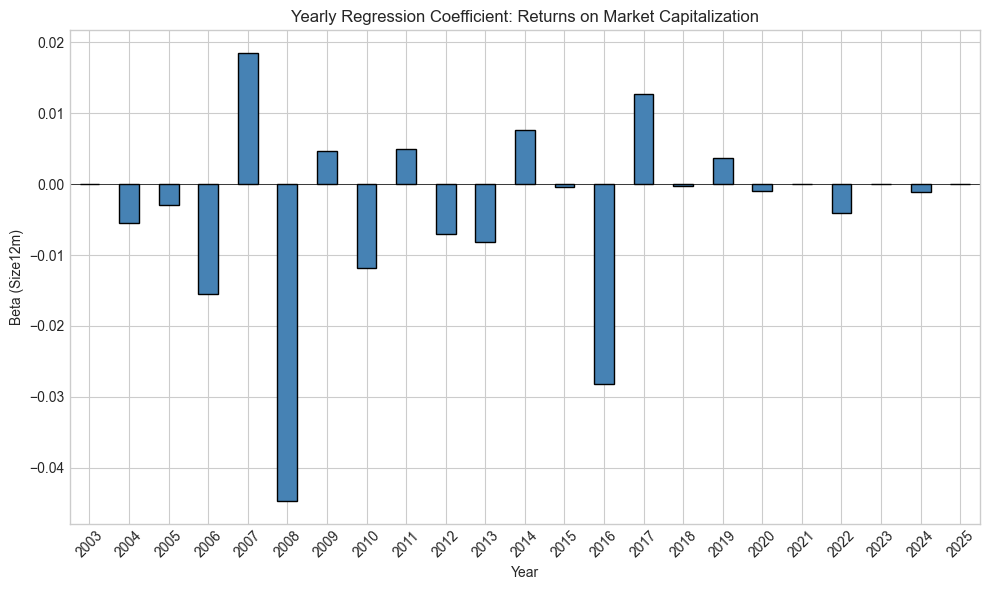


Mean beta: -0.004132
Std of beta: 0.014249
Years with positive beta: 6 / 23


In [14]:
#| label: fig-conceptdriftemp
#| fig-cap: "Variations in betas with respect to market capitalization."

# Compute yearly beta for size_avg_252d (market cap proxy)
def get_beta(group):
    """Get regression coefficient for size_avg_252d."""
    X = sm.add_constant(group['size_avg_252d'])
    y = group['R1M']
    try:
        model = OLS(y, X).fit()
        return model.params['size_avg_252d']
    except:
        return np.nan

yearly_betas = data_ml.groupby('year').apply(get_beta)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
yearly_betas.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Beta (size_avg_252d)')
ax.set_title('Yearly Regression Coefficient: Returns on Market Capitalization')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMean beta: {yearly_betas.mean():.6f}")
print(f"Std of beta: {yearly_betas.std():.6f}")
print(f"Years with positive beta: {(yearly_betas > 0).sum()} / {len(yearly_betas)}")

The bars in the figure highlight the concept drift: overall, the relationship between capitalization and returns may be negative (the **size effect**). Sometimes it is markedly negative, sometimes, not so much, and sometimes it even reverses. The ability of capitalization to explain returns is time-varying and models must adapt accordingly.

### Detecting Concept Drift

Modern machine learning provides tools to detect when concept drift occurs. Below, we implement a simple drift detection method based on monitoring prediction errors over time.

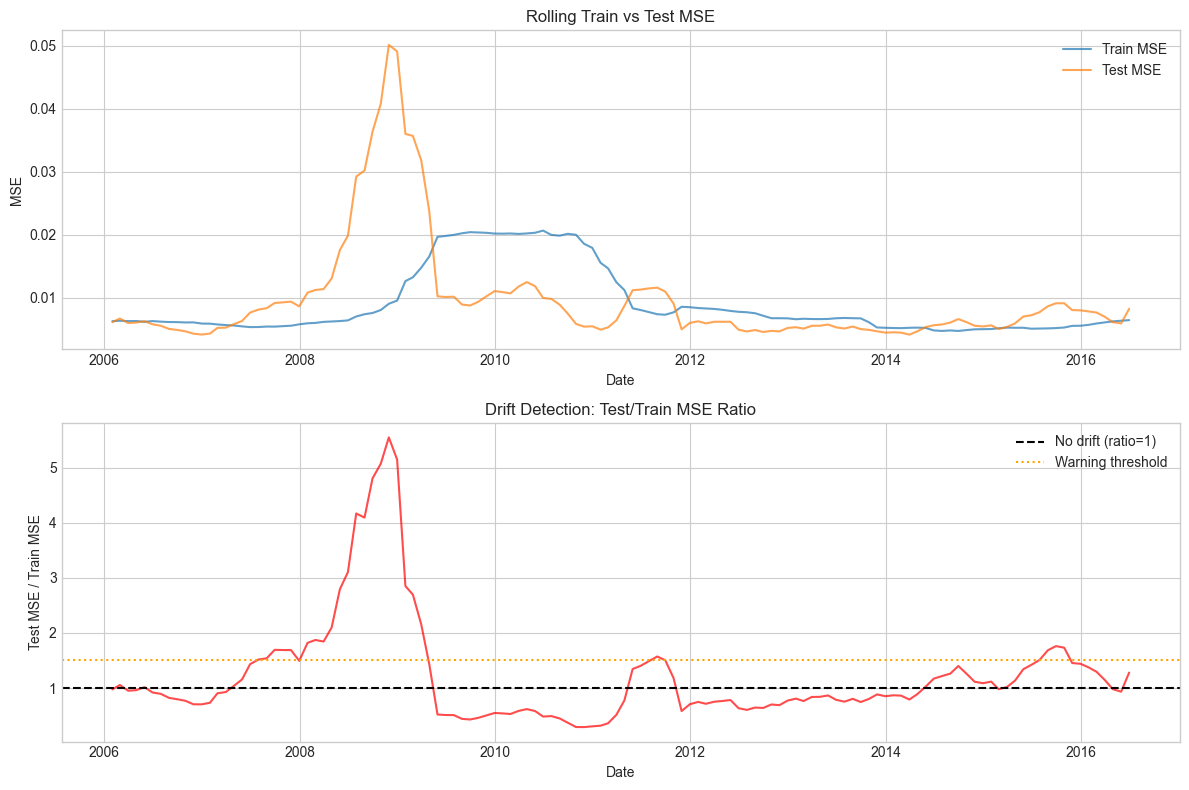


Drift Statistics:
Mean drift ratio: 1.221
Max drift ratio: 5.549
Periods with ratio > 1.5: 26


In [15]:
#| label: fig-drift_detection
#| fig-cap: "Concept drift detection via rolling prediction errors."

from sklearn.linear_model import LinearRegression

# Simple drift detection: monitor rolling prediction errors
def detect_drift_rolling(data, features, target, window_train=36, window_test=12):
    """
    Detect drift by monitoring rolling prediction errors.
    Train on window_train months, test on next window_test months.
    """
    # Get unique dates
    dates = sorted(data['date'].unique())
    
    results = []
    
    for i in range(window_train, len(dates) - window_test):
        train_dates = dates[i-window_train:i]
        test_dates = dates[i:i+window_test]
        
        train_data = data[data['date'].isin(train_dates)]
        test_data = data[data['date'].isin(test_dates)]
        
        if len(train_data) < 100 or len(test_data) < 50:
            continue
        
        # Train model
        X_train = train_data[features].dropna()
        y_train = train_data.loc[X_train.index, target]
        
        X_test = test_data[features].dropna()
        y_test = test_data.loc[X_test.index, target]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Compute errors
        train_mse = np.mean((y_train - model.predict(X_train))**2)
        test_mse = np.mean((y_test - model.predict(X_test))**2)
        
        results.append({
            'date': dates[i],
            'train_mse': train_mse,
            'test_mse': test_mse,
            'drift_ratio': test_mse / train_mse if train_mse > 0 else np.nan
        })
    
    return pd.DataFrame(results)

# Run drift detection
drift_results = detect_drift_rolling(
    training_sample, 
    features_short, 
    'R1M',
    window_train=24,
    window_test=6
)

# Plot drift ratio over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: MSE over time
axes[0].plot(drift_results['date'], drift_results['train_mse'], label='Train MSE', alpha=0.7)
axes[0].plot(drift_results['date'], drift_results['test_mse'], label='Test MSE', alpha=0.7)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('MSE')
axes[0].set_title('Rolling Train vs Test MSE')
axes[0].legend()

# Plot 2: Drift ratio
axes[1].plot(drift_results['date'], drift_results['drift_ratio'], color='red', alpha=0.7)
axes[1].axhline(y=1, color='black', linestyle='--', label='No drift (ratio=1)')
axes[1].axhline(y=1.5, color='orange', linestyle=':', label='Warning threshold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Test MSE / Train MSE')
axes[1].set_title('Drift Detection: Test/Train MSE Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nDrift Statistics:")
print(f"Mean drift ratio: {drift_results['drift_ratio'].mean():.3f}")
print(f"Max drift ratio: {drift_results['drift_ratio'].max():.3f}")
print(f"Periods with ratio > 1.5: {(drift_results['drift_ratio'] > 1.5).sum()}")

### Online learning

Online learning refers to a subset of machine learning in which new information arrives progressively and the integration of this flow is performed iteratively (the term '*online*' is not linked to the internet). In order to take the latest data updates into account, it is imperative to update the model.

The problem is that if a 2019 model is trained on data from 2010 to 2019, the (dynamic) 2020 model will have to be re-trained with the whole dataset including the latest points from 2020. This can be heavy and including just the latest points in the learning process would substantially decrease its computational cost. In neural networks, the sequential batch updating of weights can allow a progressive change in the model.

The simplest example of online learning is the Widrow-Hoff algorithm (originally from @widrow1960adaptive). Suppose the model is linear, that is $\textbf{y}=\textbf{Xb}+\textbf{e}$ and that the amount of data is both massive and coming in at a high frequency. A simple and heuristic way to update the values of $\textbf{b}$ is to compute

$$\textbf{b}_{t+1} \longleftarrow \textbf{b}_t-\eta (\textbf{x}_t\textbf{b}-y_t)\textbf{x}_t',$$

where $\textbf{x}_t$ is the row vector of instance $t$. The justification is simple. The quadratic error $(\textbf{x}_t\textbf{b}-y_t)^2$ has a gradient with respect to $\textbf{b}$ equal to $2(\textbf{x}_t\textbf{b}-y_t)\textbf{x}_t'$; therefore, the above update is a simple example of gradient descent. $\eta$ must of course be quite small: if not, each new point will considerably alter $\textbf{b}$, thereby resulting in a volatile model.

Datasets are indexed by time: we write $\textbf{X}_t$ and $\textbf{y}_t$ for features and labels. Time has a bounded horizon $T$. The machine learning model depends on some parameters $\boldsymbol{\theta}$ and we denote it with $f_{\boldsymbol{\theta}}$. At time $t$ (when dataset ($\textbf{X}_t$, $\textbf{y}_t$) is gathered), the loss function $L$ naturally depends on the data and on the model via $\boldsymbol{\theta}_t$ which are the parameter values fitted to the time-$t$ data. The key quantity in online learning is the regret over the whole time sequence:

$$
R_T=\sum_{t=1}^TL_t(\boldsymbol{\theta}_t)-\underset{\boldsymbol{\theta}^*\in \boldsymbol{\Theta}}{\inf} \ \sum_{t=1}^TL_t(\boldsymbol{\theta}^*).
$$ (eq:regret)

The regret is the total loss incurred by the models $\boldsymbol{\theta}_t$ minus the minimal loss that could have been obtained with full knowledge of the data sequence (hence computed in hindsight). The basic methods in online learning are in fact quite similar to the batch-training of neural networks. The updating of the parameter is based on

$$
\textbf{z}_{t+1}=\boldsymbol{\theta}_t-\eta_t\nabla L_t(\boldsymbol{\theta}_t),
$$ (eq:online1)

where $\nabla L_t(\boldsymbol{\theta}_t)$ denotes the gradient of the current loss $L_t$.

In [16]:
# Online Learning Implementation: Widrow-Hoff / LMS Algorithm

def online_sgd_regression(X, y, learning_rate=0.001, n_passes=1):
    """
    Online Stochastic Gradient Descent for linear regression.
    
    Updates weights one sample at a time.
    """
    n_samples, n_features = X.shape
    
    # Initialize weights
    weights = np.zeros(n_features)
    bias = 0
    
    # Track history
    weight_history = [weights.copy()]
    loss_history = []
    
    for _ in range(n_passes):
        for i in range(n_samples):
            # Prediction
            pred = np.dot(X[i], weights) + bias
            
            # Error
            error = pred - y[i]
            
            # Update (gradient descent step)
            weights = weights - learning_rate * error * X[i]
            bias = bias - learning_rate * error
            
            # Track
            if i % 1000 == 0:
                weight_history.append(weights.copy())
                loss_history.append(error**2)
    
    return weights, bias, weight_history, loss_history

# Prepare data for online learning
X_online = training_sample[features_short].dropna().values
y_online = training_sample.loc[training_sample[features_short].dropna().index, 'R1M'].values

# Standardize features
X_mean = X_online.mean(axis=0)
X_std = X_online.std(axis=0)
X_online_scaled = (X_online - X_mean) / (X_std + 1e-8)

# Run online learning
weights_online, bias_online, weight_hist, loss_hist = online_sgd_regression(
    X_online_scaled, y_online, learning_rate=0.0001, n_passes=3
)

print("Online SGD Results:")
print("="*50)
for i, feat in enumerate(features_short):
    print(f"{feat}: {weights_online[i]:.6f}")
print(f"Bias: {bias_online:.6f}")

Online SGD Results:
Div_yld: -0.004103
EPS: -0.001899
size_avg_252d: -0.017113
mom_252: -0.026692
OCF_Growth_1Y: 0.003483
PB: 0.008164
vol_252: -0.001571
Bias: 0.017589


In [17]:
#| label: fig-online_learning
#| fig-cap: "Evolution of weights during online learning."

# Compare with batch OLS
from sklearn.linear_model import LinearRegression
batch_model = LinearRegression()
batch_model.fit(X_online_scaled, y_online)

# Plot weight evolution
weight_hist_arr = np.array(weight_hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight evolution
for i, feat in enumerate(features_short):
    axes[0].plot(weight_hist_arr[:, i], label=feat, alpha=0.7)
axes[0].set_xlabel('Update Step (x1000)')
axes[0].set_ylabel('Weight Value')
axes[0].set_title('Weight Evolution During Online Learning')
axes[0].legend(loc='best', fontsize=8)

# Compare final weights
x_pos = np.arange(len(features_short))
width = 0.35
axes[1].bar(x_pos - width/2, weights_online, width, label='Online SGD')
axes[1].bar(x_pos + width/2, batch_model.coef_, width, label='Batch OLS')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(features_short, rotation=45, ha='right')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Online vs Batch Regression Coefficients')
axes[1].legend()

plt.tight_layout()
plt.show()

We end this section with a historical note. Some of the ideas from online learning stem from the financial literature and from the concept of **universal portfolios** originally coined by @cover1991universal in particular. The setting is the following. The function $f$ is assumed to be linear $f(\textbf{x}_t)=\boldsymbol{\theta}'\textbf{x}_t$ and the data $\textbf{x}_t$ consists of asset returns, thus, the values are portfolio returns as long as $\boldsymbol{\theta}'\textbf{1}_N=1$ (the budget constraint). The loss functions $L_t$ correspond to a concave utility function (e.g., logarithmic) and the regret is reversed:

$$R_T=\underset{\boldsymbol{\theta}^*\in \boldsymbol{\Theta}}{\sup} \ \sum_{t=1}^TL_t(\textbf{r}_t'\boldsymbol{\theta}^*)-\sum_{t=1}^TL_t(\textbf{r}_t'\boldsymbol{\theta}_t),$$

where $\textbf{r}_t'$ are the returns. Thus, the program is transformed to maximize a concave function. Several articles (often from the Computer Science or ML communities) have proposed solutions to this type of problems: @blum1999universal, @agarwal2006algorithms and @hazan2007logarithmic. The literature on online portfolio allocation is reviewed in @li2014online and outlined in more details in @li2018online.

### Homogeneous transfer learning

This subsection is mostly conceptual. The ideas behind transfer learning can be valuable in that they can foster novel ideas, which is why we briefly present them below.

Transfer learning has been surveyed numerous times. One classical reference is @pan2009survey, but @weiss2016survey is more recent and more exhaustive. Suppose we are given two datasets $D_S$ (source) and $D_T$ (target). Each dataset has its own features $\textbf{X}^S$ and $\textbf{X}^T$ and labels $\textbf{y}^S$ and $\textbf{y}^T$. In classical supervised learning, the patterns of the target set are learned only through $\textbf{X}^T$ and $\textbf{y}^T$. Transfer learning proposes to improve the function $f^T$ (obtained by minimizing the fit $y_i^T=f^T(\textbf{x}_i^T)+\epsilon^T_i$ on the target data) via the function $f^S$ (from $y_i^S=f^S(\textbf{x}_i^S)+\varepsilon^S_i$ on the source data). Homogeneous transfer learning is when the feature space does not change, which is the case in our setting. In asset management, this may not always be the case if for instance new predictors are included (e.g., based on alternative data like sentiment, satellite imagery, credit card logs, etc.).

There are many subcategories in transfer learning depending on what changes between the source $S$ and the target $T$: is it the feature space, the distribution of the labels, and/or the relationship between the two? The latter case is of interest in finance because the link with non-stationarity is evident: it is when the model $f$ in $\textbf{y}=f(\textbf{X})$ changes through time. In transfer learning jargon, it is written as $P[\textbf{y}^S|\textbf{X}^S]\neq P[\textbf{y}^T|\textbf{X}^T]$: the conditional law of the label knowing the features is not the same when switching from the source to the target.

An important and elegant result in the theory was proven by @ben2010theory in the case of binary classification. We consider $f$ and $h$ two classifiers with values in $\{0,1 \}$. The average error between the two over the domain $S$ is defined by

$$\epsilon_S(f,h)=\mathbb{E}_S[|f(\textbf{x})-h(\textbf{x})|].$$

Then,

$$
\epsilon_T(f_T,h)\le \epsilon_S(f_S,h)+\underbrace{2 \sup_B|P_S(B)-P_T(B)|}_{\text{ difference between domains }} + \underbrace{ \min\left(\mathbb{E}_S[|f_S(\textbf{x})-f_T(\textbf{x})|],\mathbb{E}_T[|f_S(\textbf{x})-f_T(\textbf{x})|]\right)}_{\text{difference between the two learning tasks}},
$$

where $P_S$ and $P_T$ denote the distribution of the two domains. The above inequality is a bound on the generalization performance of $h$. If we take $f_S$ to be the best possible classifier for $S$ and $f_T$ the best for $T$, then the error generated by $h$ in $T$ is smaller than the sum of three components:

- the error in the $S$ space;
- the distance between the two domains (by how much the data space has shifted);
- the distance between the two best models (generators).

One solution that is often mentioned in transfer learning is instance weighting. In machine learning, we seek to minimize

$$
\epsilon_T(f)=\mathbb{E}_T\left[L(\text{y},f(\textbf{X})) \right],
$$

where $L$ is some loss function. This can be arranged:

$$
\epsilon_T(f)=\mathbb{E}_S \left[\frac{P_T(\textbf{y},\textbf{X})}{P_S(\textbf{y},\textbf{X})} L(\text{y},f(\textbf{X})) \right]
$$

The key quantity is thus the transition ratio $\frac{P_T(\textbf{y},\textbf{X})}{P_S(\textbf{y},\textbf{X})}$ (Radon–Nikodym derivative under some assumptions). Of course this ratio is largely inaccessible in practice, but it is possible to find a weighting scheme (over the instances) that yields improvements over the error in the target space. The weighting scheme can be binary, thereby simply excluding some observations in the computation of the error. Simply removing observations from the training sample can have beneficial effects.

More generally, the above expression can be viewed as a theoretical invitation for user-specified instance weighting. In the asset allocation parlance, this can be viewed as introducing views as to which observations are the most interesting, e.g., value stocks can be allowed to have a larger weight in the computation of the loss if the user believes they carry more relevant information.

We close this topic by mentioning a practical application of transfer learning developed in @koshiyama2020quantnet. The authors propose a neural network architecture that allows to share the learning process from different strategies across several markets. This method is, among other things, aimed at alleviating the backtest overfitting problem.